# shapefile to .map

### description

this notebooks creates a clonemap and landmask from provided shapefile/shapefiles for use in PCRGLOBWB modelling. Tested using GRDC station-catchment shapefiles. 

### Requirements

This notebook requires a conda environment with PCRaster.

### Installation

Create and set up the environment:

```bash
conda create -n pcraster_env python=3.10
conda activate pcraster_env

mamba install -c conda-forge \
  pcraster \
  geopandas \
  rasterio \
  xarray \
  numpy \
  matplotlib \
  jupyter \
  ipykernel\
  fiona

python -m ipykernel install --user --name pcraster_env --display-name "Python (pcraster)"
```

### Usage

* Start Jupyter Notebook
* Select the kernel: **Python (pcraster)**

### ToDo

* check for valid coordinate system
* combine functions to reduce manual work



In [1]:
# check if installed correctly

import pcraster as pcr
import pcraster.matplotlib as pcrplt

print("PCRaster works!")

PCRaster works!


In [2]:
import subprocess
from collections.abc import Sequence
from pathlib import Path
from typing import Union

import geopandas as gpd
import numpy as np
import pandas as pd
import pcraster.numpy_operations as pcrnp
from rasterio.features import rasterize
from rasterio.transform import from_origin

# Helper Functions

In [ ]:
def create_clonemap(lonmin, latmin, lonmax, latmax, forcing_resolution, catchment):
    """Create new clonemap compatible with forcing data resolution.

    Made by Rolf Hut and Mark Melotto?, slightly modified by Andre van der Veen
    """
    dlon = lonmax - lonmin
    dlat = latmax - latmin

    msg = (
        "The clonemap extent divided by the forcing resolution must yield"
        " an integer number of grid cells."
    )
    assert (
        dlon % forcing_resolution == 0
    ), f"Longitudes not compatible. {msg} Currently = {dlon % forcing_resolution}"
    assert (
        dlat % forcing_resolution == 0
    ), f"Latitudes not compatible. {msg} Currently = {dlat % forcing_resolution}"

    clonemap_dir = "/data/shared/parameter-sets/pcrglobwb_global/global_05min/cloneMaps"  # location of global clonemap on /data/shared, requires permission?
    globalclonemap = clonemap_dir + "/clone_global_05min.map"
    outputclonemap = f"./{catchment.lower()}_05min_clone.map"  # copy to clonemap dir after ensuring it is correct

    subprocess.call(
        f"gdal_translate -of PCRaster {globalclonemap} -projwin "
        f"{lonmin} {latmax} {lonmax} {latmin} {outputclonemap}",
        shell=True,
    )
    return outputclonemap


def shapefile_to_mask(clonemap, shapefile, output_mask, mv=-9999):
    """
    Create a PCRaster mask based on a shapefile and existing cloneMap.
    Inside shapefile values set to True, outside of the shapefile to 'missing values'
    """
    # set original clonemap as clonemap to ensure grids align, read Rasterinfo from cloneMap
    pcr.setclone(clonemap)
    clone = pcr.clone()
    rows = clone.nrRows()
    cols = clone.nrCols()
    cellsize = clone.cellSize()
    xUL = clone.west()  # left coordinate
    yUL = clone.north()  # top coordinate

    # Read shapefile geometries
    gdf = gpd.read_file(shapefile)

    shapes = [(geom, 1) for geom in gdf.geometry]

    # make numpy raster with values outside shape to np.nan
    transform = from_origin(xUL, yUL, cellsize, cellsize)  # square cells so xsize, ysize = cellsize
    raster = rasterize(
        shapes, out_shape=(rows, cols), transform=transform, fill=np.nan, dtype="float32"
    )

    # Convert to PCRaster map, with np.nan to missing values
    arr = np.where(np.isnan(raster), mv, raster)
    pcr_map = pcrnp.numpy2pcr(pcr.Scalar, arr, mv)

    # make sure inside shapefile is True
    pcr_map = pcr_map == 1

    # save output
    pcr.report(pcr_map, output_mask)

    print(f"Mask saved as {output_mask}")
    return output_mask


def shapefiles_to_mask(clonemap, shapefiles, output_mask, mv=-9999):
    """
    Create a PCRaster mask based on several shapefiles and existing cloneMap.
    Inside shapefile values set to True, outside of the shipefile to 'missing values'
    """
    # set original clonemap as clonemap to ensure grids align, read Rasterinfo from cloneMap
    pcr.setclone(clonemap)
    clone = pcr.clone()
    rows = clone.nrRows()
    cols = clone.nrCols()
    cellsize = clone.cellSize()
    xUL = clone.west()  # left coordinate
    yUL = clone.north()  # top coordinate

    # Read shapefile geometries
    gdfs = [gpd.read_file(shp) for shp in shapefiles]
    gdf = gpd.GeoDataFrame(pd.concat(gdfs, ignore_index=True), crs=gdfs[0].crs)

    ####--------------------------------------------------------------#######
    # double check this TODO
    ####--------------------------------------------------------------#######

    buffer_cells = 10
    buffer_dist = buffer_cells * cellsize
    gdf["geometry"] = gdf.geometry.buffer(buffer_dist)

    shapes = [(geom, 1) for geom in gdf.geometry]

    # make numpy raster with values outside shape to np.nan
    transform = from_origin(xUL, yUL, cellsize, cellsize)  # square cells so xsize, ysize = cellsize
    raster = rasterize(
        shapes,
        out_shape=(rows, cols),
        transform=transform,
        fill=np.nan,
        dtype="float32",
        # all_touched=True
    )

    # Convert to PCRaster map, with np.nan to missing values
    arr = np.where(np.isnan(raster), mv, raster)
    pcr_map = pcrnp.numpy2pcr(pcr.Scalar, arr, mv)

    # make sure inside shapefile is True
    pcr_map = pcr_map == 1

    # save output
    pcr.report(pcr_map, output_mask)

    print(f"Mask saved as {output_mask}")
    return output_mask


def get_integer_multiple_bounds(
    shapefiles: Union[str, Path, Sequence[Union[str, Path]]],
    multiple: int = 3,
):
    """
    docstring
    docstring
    docstring
    """

    # make list
    if isinstance(shapefiles, (str, Path)):
        shapefiles = [shapefiles]

    # combine to one shapefile
    gdfs = [gpd.read_file(shp) for shp in shapefiles]
    gdf = gpd.GeoDataFrame(
        pd.concat(gdfs, ignore_index=True),
        crs=gdfs[0].crs,
    )

    # --- original bounds ---
    lon_min, lat_min, lon_max, lat_max = gdf.total_bounds

    # --- convert to integer bounds ---
    lon_min_i = int(np.floor(lon_min))
    lat_min_i = int(np.floor(lat_min))
    lon_max_i = int(np.ceil(lon_max))
    lat_max_i = int(np.ceil(lat_max))

    # --- helper to expand to multiple ---
    def expand_to_multiple(min_val, max_val, multiple):
        extent = max_val - min_val
        remainder = extent % multiple
        if remainder != 0:
            max_val += multiple - remainder
        return min_val, max_val

    lon_min_f, lon_max_f = expand_to_multiple(lon_min_i, lon_max_i, multiple)
    lat_min_f, lat_max_f = expand_to_multiple(lat_min_i, lat_max_i, multiple)

    return lon_min_f, lat_min_f, lon_max_f, lat_max_f

# Make Maps

<img src="shapefiles_converter/Test_shapes.png" alt="Overview_Shapefiles" width="500">

In [4]:
# Dummy files for testing purposes
shp_id1 = "shapefiles_converter/id_1.shp"
shp_id2 = "shapefiles_converter/id_2.shp"
shp_id5 = "shapefiles_converter/id_5.shp"

chatly_shp = "/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/data/shapefiles/Chatly_GRDC/Chatly_GRDC.shp"
kazalinsk_shp = "/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/data/shapefiles/Kazalinsk_GRDC/Kazalinsk_GRDC.shp"

In [5]:
# Determine bounding box
lon_min_f, lat_min_f, lon_max_f, lat_max_f = get_integer_multiple_bounds(
    [chatly_shp, kazalinsk_shp],  #   <----- add shapefiles here
    multiple=3,  # makes sure resolution is always correct
)
print(lon_min_f, lat_min_f, lon_max_f, lat_max_f)

59 34 80 49


In [6]:
# Create the clonemap -  a rectangle which is the bounding box PCR-GLOBWB can read.

forcing_resolution = 0.75  # leave this at 0.75 for now
catchment_name = "aral_basin_ad_sd_rivers_buffer_10"  # set name of file here
catchment_name = catchment_name.lower()  # converts to lowercase
create_clonemap(lon_min_f, lat_min_f, lon_max_f, lat_max_f, forcing_resolution, catchment_name)

Input file size is 4320, 2160
0...10...20...30...40...50...60...70...80...90...100 - done.


'./aral_basin_ad_sd_rivers_buffer_10_05min_clone.map'

In [7]:
# Existing clonemap
clonemap_file = f"{catchment_name}_05min_clone.map"

# Output mask file
mask_file = f"{catchment_name}_05min_mask.map"

# Create landMask - an area within the clonemap that PCRGLOB will model - generally a catchment
shapefiles_to_mask(
    clonemap_file,  # existing clonemap
    [chatly_shp, kazalinsk_shp],  #   <----- add shapefiles here
    mask_file,  # name of landmask to be generated
)

/tmp/ipykernel_6944/3671239538.py:94: UserWarning: Geometry is in a geographic CRS. Results from 'buffer' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf["geometry"] = gdf.geometry.buffer(buffer_dist)


Mask saved as aral_basin_ad_sd_rivers_buffer_10_05min_mask.map


'aral_basin_ad_sd_rivers_buffer_10_05min_mask.map'

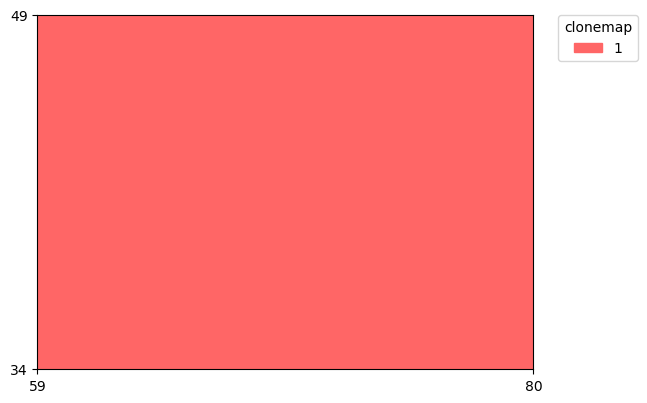

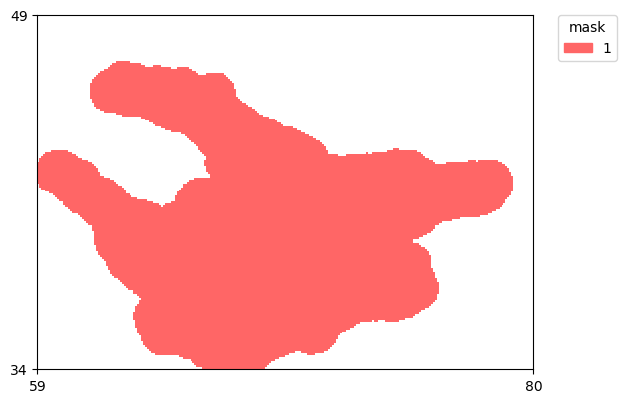

In [8]:
# Plot the result
clonemap = pcr.readmap(clonemap_file)
mask = pcr.readmap(mask_file)

# plot clonemap
pcrplt.plot(clonemap)  # , title="Clonemap") #, filename="clonemap_plot.png")

# plot landmask
pcrplt.plot(mask)